# IIDS67682 Assignment 2: Transformers and representation learning
Student ID: 14210037

In [1]:
# HTTP download info
import requests
# PyTorch
import torch
# For dislaying images
from PIL import Image
import matplotlib.pyplot as plt
# Transformers
from transformers import ViTImageProcessor, ViTForImageClassification, TrainingArguments, Trainer, set_seed
# HuggingFace 
import accelerate
import transformers
# Matrix operations
import numpy as np
import pandas as pd
from datasets import Dataset, DatasetDict
from tqdm import tqdm
from collections import Counter
# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, adjusted_rand_score, classification_report
from sklearn.decomposition import PCA
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
# device = "gpu"

/opt/conda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 0. Data import

In [2]:
from transformers import set_seed
set_seed(123)

In [3]:
model_name = "facebook/deit-tiny-patch16-224"                       # the model name
image_processor = ViTImageProcessor.from_pretrained(model_name)   # load the image processor
model = ViTForImageClassification.from_pretrained(model_name)     # loading the pre-trained model

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 834.87it/s, Materializing param=vit.layernorm.weight]                                 


**Load Dataset and convert npz into hugging face compatible**

In [4]:
def npz_to_hf_dataset(path):
    data = np.load(path, allow_pickle=False)
    
    images = [Image.fromarray(img.astype(np.uint8)) for img in data["images"]]
    labels = data["labels"].tolist()

    return Dataset.from_dict({
        "image": images,
        "label": labels
    })

ds = DatasetDict({
    "train": npz_to_hf_dataset("Assignment 2/assignment_2_data/assignment_train.npz"),
    "validation": npz_to_hf_dataset("Assignment 2/assignment_2_data/assignment_val.npz"),
    "test": npz_to_hf_dataset("Assignment 2/assignment_2_data/assignment_test.npz"),
})

In [5]:
print("Total number of training images:", len(ds["train"]))
print("Total number of validation images:", len(ds["validation"]))
print("Total number of test images:", len(ds["test"]))

Total number of training images: 26998
Total number of validation images: 3001
Total number of test images: 2154


In [6]:
labels = ['adipose', 'background', 'debris', 'lymphocytes', 
          'mucus', 'smooth muscle', 'normal colon mucosa', 
          'cancer-associated stroma', 'colorectal adenocarcinoma epithelium']
NUM_CLASSES = len(labels)

In [6]:
# Define mapping between numeric labels and tissue classes
# This is required for interpretability of results and figures

label_map = {
    0: "adipose",
    1: "background",
    2: "debris",
    3: "lymphocytes",
    4: "mucus",
    5: "smooth muscle",
    6: "normal colon mucosa",
    7: "cancer-associated stroma",
    8: "colorectal adenocarcinoma epithelium"
}

# Reverse mapping (useful for predictions)
id2label = label_map
label2id = {v: k for k, v in label_map.items()}

# Example: convert numeric predictions to class names
def decode_labels(preds):
    return [id2label[p] for p in preds]

# 1. Data exploration

In [7]:
train_labels = ds["train"]["label"]
val_labels   = ds["validation"]["label"]
test_labels  = ds["test"]["label"]

def get_label_distribution(labels):
    return Counter(labels)

print("Train:", get_label_distribution(train_labels))
print("Validation:", get_label_distribution(val_labels))
print("Test:", get_label_distribution(test_labels))

Train: Counter({8: 3809, 5: 3525, 3: 3129, 2: 3092, 0: 2923, 1: 2918, 7: 2860, 4: 2384, 6: 2358})
Validation: Counter({8: 433, 5: 391, 3: 351, 7: 332, 2: 330, 1: 327, 0: 299, 4: 277, 6: 261})
Test: Counter({0: 406, 8: 377, 4: 320, 1: 248, 6: 235, 3: 197, 5: 164, 7: 122, 2: 85})


In [8]:
def plot_label_distribution(labels, title, filename=None):
    counts = Counter(labels)
    classes = sorted(counts.keys())
    values = np.array([counts[c] for c in classes])

    total = values.sum()
    percentages = values / total * 100

    fig, ax1 = plt.subplots(figsize=(7,5))

    # Left axis: Counts
    bars = ax1.bar(classes, values, color="#88ccee", label="Count")
    ax1.set_xlabel("Class index")
    ax1.set_ylabel("Count")
    ax1.set_title(title)
    ax1.grid(axis="y", linestyle="--", alpha=0.5)

    # Right axis: Percentage
    ax2 = ax1.twinx()
    ax2.set_ylabel("Percentage (%)")
    ax2.set_ylim(0, percentages.max() * 1.2)
    ax2.set_yticks(np.linspace(0, percentages.max(), 5))
    ax2.set_yticklabels([f"{p:.1f}%" for p in np.linspace(0, percentages.max(), 5)])

    # Annotation: count + percentage on each bar
    for i, bar in enumerate(bars):
        h = bar.get_height()
        pct = percentages[i]
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            h,             # put text above bar
            f"{h}\n ({pct:.1f}%)",
            ha="center", va="bottom", fontsize=8
        )

    plt.tight_layout()
    
    if filename is not None:
        plt.savefig(filename, dpi=200)
        print(f"Saved: {filename}")

    plt.show()

Saved: fig_a_train.png


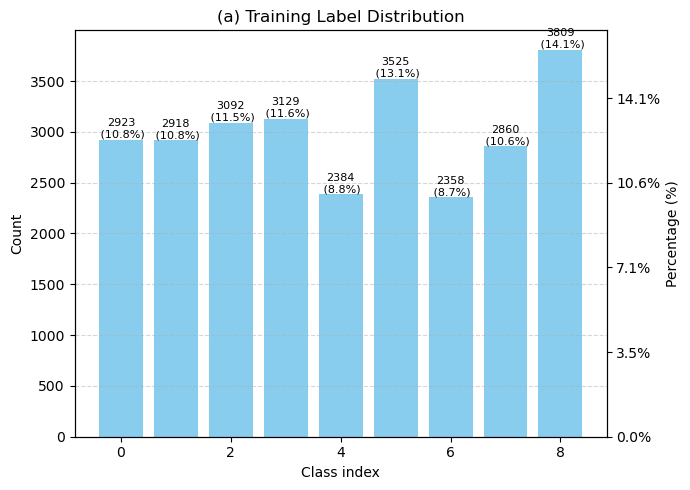

Saved: fig_b_val.png


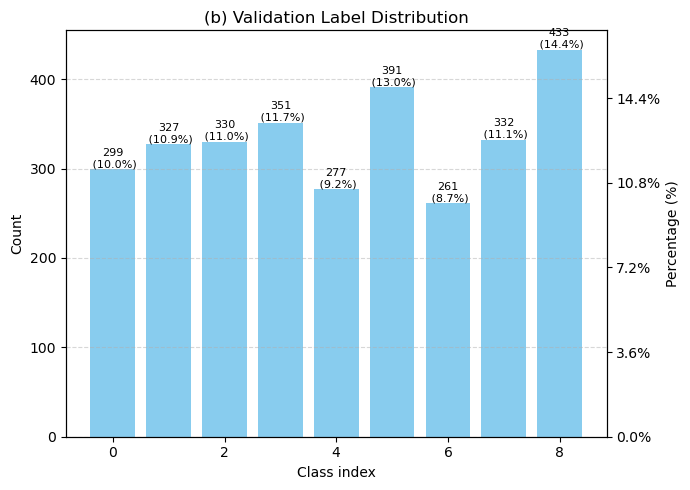

Saved: fig_c_test.png


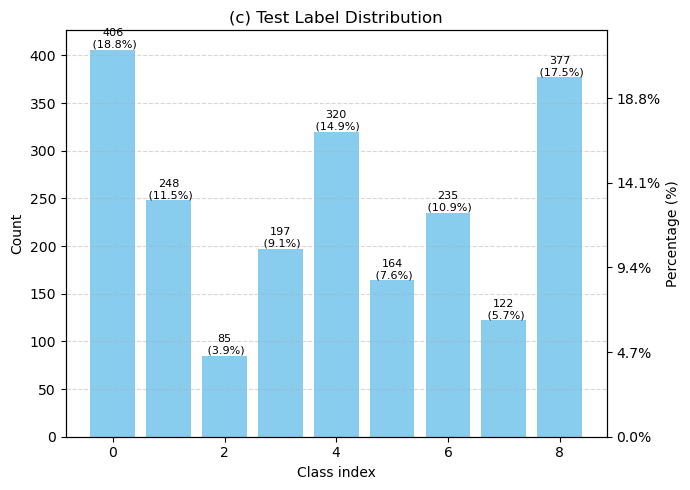

In [9]:
plot_label_distribution(train_labels, "(a) Training Label Distribution", "fig_a_train.png")
plot_label_distribution(val_labels,   "(b) Validation Label Distribution", "fig_b_val.png")
plot_label_distribution(test_labels,  "(c) Test Label Distribution", "fig_c_test.png")

In [10]:
print(type(test_labels))
print(test_labels[:10])

<class 'list'>
[4, 8, 8, 6, 8, 6, 0, 0, 2, 0]


Saved: fig3_sample_images.png


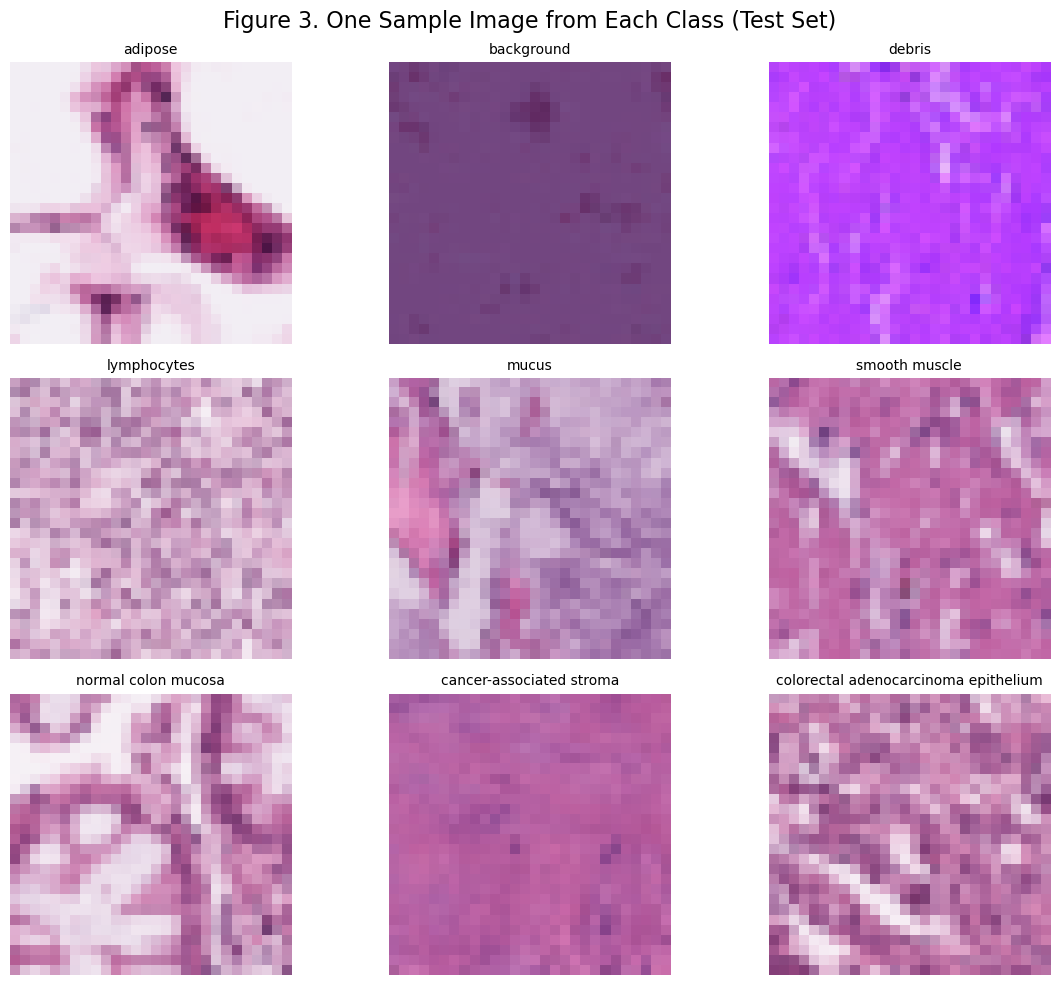

In [12]:
test_images = np.array([np.array(img) for img in ds["test"]["image"]])
test_labels = np.array(ds["test"]["label"], dtype=int)

# Sample images from testing dataset
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle("Figure 3. One Sample Image from Each Class (Test Set)", fontsize=16)

for class_id in range(len(labels)):
    ax = axes[class_id // 3, class_id % 3]
    idx = np.where(test_labels == class_id)[0][0]  # first  
    
    ax.imshow(test_images[idx])
    ax.set_title(labels[class_id], fontsize=10)
    ax.axis("off")

plt.tight_layout()

plt.savefig("fig3_sample_images.png", dpi=200, bbox_inches="tight")
print("Saved: fig3_sample_images.png")

plt.show()

# 2. Model architecture

In [13]:
def transform(examples):
  # convert all images to RGB format, then preprocessing it using the image processor
  inputs = image_processor([img.convert("RGB") for img in examples["image"]], return_tensors="pt")
    
  inputs["labels"] = examples["label"]

  return inputs
    
dataset = ds.with_transform(transform)


In [14]:
def collate_fn(batch):
  return {
      "pixel_values": torch.stack([x["pixel_values"] for x in batch]),
      "labels": torch.tensor([x["labels"] for x in batch]),
  }

In [15]:
# load the ViT model
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=len(labels),
    id2label={str(i): c for i, c in enumerate(labels)},
    label2id={c: str(i) for i, c in enumerate(labels)},
    ignore_mismatched_sizes=True,
)
print(model)

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 32927.49it/s]
ViTForImageClassification LOAD REPORT from: facebook/deit-tiny-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([9])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 192]) vs model:torch.Size([9, 192])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=192, out_features=192, bias=True)
              (key): Linear(in_features=192, out_features=192, bias=True)
              (value): Linear(in_features=192, out_features=192, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=192, out_features=192, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=192, out_features=768, bias=True)
            (intermedi

In [16]:
# check size of the embedding of each token
sample = dataset["train"][0] 

pixel_values = sample["pixel_values"].unsqueeze(0).to(model.device)

with torch.no_grad():
    embeddings = model.vit.embeddings(pixel_values)

print("Embedding shape:", embeddings.shape)

Embedding shape: torch.Size([1, 197, 192])


# 3. Fine-tuning strategy

In [17]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [18]:
training_args = TrainingArguments(
    output_dir="vit_finetune",
    save_strategy="no",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    weight_decay=0.01,
    logging_dir="logs",
    remove_unused_columns=False,
    seed=123,
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [19]:
# Re-initialize model
def make_model():
    return ViTForImageClassification.from_pretrained(
        model_name,
        num_labels=NUM_CLASSES,
        id2label={str(i): c for i, c in enumerate(labels)},
        label2id={c: str(i) for i, c in enumerate(labels)},
        ignore_mismatched_sizes=True,
    )

## 3.1. Strategy A: Fine-tuning — classifier head only
All 12 ViT encoder layers are frozen. Only the linear classifier head is trained. This treats the pre-trained encoder as a fixed feature extractor, testing whether ImageNet representations are directly transferable to histological images.

In [20]:
model_A = make_model()

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 26176.77it/s]
ViTForImageClassification LOAD REPORT from: facebook/deit-tiny-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([9])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 192]) vs model:torch.Size([9, 192])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [21]:
# freeze entire ViT encoder
for param in model_A.vit.parameters():
    param.requires_grad = False 
# unfreeze only classifier head 
for param in model_A.classifier.parameters():
    param.requires_grad = True

In [22]:
# Check which parameters are trainable
for name, param in model_A.named_parameters():
    print(name, param.requires_grad)

vit.embeddings.cls_token False
vit.embeddings.position_embeddings False
vit.embeddings.patch_embeddings.projection.weight False
vit.embeddings.patch_embeddings.projection.bias False
vit.encoder.layer.0.attention.attention.query.weight False
vit.encoder.layer.0.attention.attention.query.bias False
vit.encoder.layer.0.attention.attention.key.weight False
vit.encoder.layer.0.attention.attention.key.bias False
vit.encoder.layer.0.attention.attention.value.weight False
vit.encoder.layer.0.attention.attention.value.bias False
vit.encoder.layer.0.attention.output.dense.weight False
vit.encoder.layer.0.attention.output.dense.bias False
vit.encoder.layer.0.intermediate.dense.weight False
vit.encoder.layer.0.intermediate.dense.bias False
vit.encoder.layer.0.output.dense.weight False
vit.encoder.layer.0.output.dense.bias False
vit.encoder.layer.0.layernorm_before.weight False
vit.encoder.layer.0.layernorm_before.bias False
vit.encoder.layer.0.layernorm_after.weight False
vit.encoder.layer.0.layer

In [23]:
trainer_A = Trainer(
    model=model_A,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
)

trainer_A.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,1.611813,1.486686,0.627458
2,1.261994,1.184763,0.682106
3,1.048683,1.034770,0.708764
4,0.964218,0.949510,0.727091
5,0.917496,0.898627,0.742752
6,0.884304,0.867394,0.748750
7,0.856484,0.850580,0.751083
8,0.853295,0.845360,0.752749


TrainOutput(global_step=13504, training_loss=1.0866053901542136, metrics={'train_runtime': 664.2824, 'train_samples_per_second': 325.139, 'train_steps_per_second': 20.329, 'total_flos': 1.0779857666712207e+18, 'train_loss': 1.0866053901542136, 'epoch': 8.0})

## 3.2. Strategy B: Fine-tuning — classifier head + last 2 encoder layers
Encoder layers 10 and 11 (0-indexed) are unfrozen in addition to the classifier head.
This allows the model to adapt its highest-level representations to the target domain while retaining the low-level features learned during ImageNet pre-training.

In [24]:
# Re-initialize model
model_B = make_model()

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 19345.08it/s]
ViTForImageClassification LOAD REPORT from: facebook/deit-tiny-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([9])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 192]) vs model:torch.Size([9, 192])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [25]:
for param in model_B.vit.parameters():
    param.requires_grad = False
for param in model_B.classifier.parameters():
    param.requires_grad = True
# last 2 encoder layer
for param in model_B.vit.encoder.layer[-2:].parameters():
    param.requires_grad = True

In [26]:
# Check which parameters are trainable
for name, param in model_B.named_parameters():
    print(name, param.requires_grad)

vit.embeddings.cls_token False
vit.embeddings.position_embeddings False
vit.embeddings.patch_embeddings.projection.weight False
vit.embeddings.patch_embeddings.projection.bias False
vit.encoder.layer.0.attention.attention.query.weight False
vit.encoder.layer.0.attention.attention.query.bias False
vit.encoder.layer.0.attention.attention.key.weight False
vit.encoder.layer.0.attention.attention.key.bias False
vit.encoder.layer.0.attention.attention.value.weight False
vit.encoder.layer.0.attention.attention.value.bias False
vit.encoder.layer.0.attention.output.dense.weight False
vit.encoder.layer.0.attention.output.dense.bias False
vit.encoder.layer.0.intermediate.dense.weight False
vit.encoder.layer.0.intermediate.dense.bias False
vit.encoder.layer.0.output.dense.weight False
vit.encoder.layer.0.output.dense.bias False
vit.encoder.layer.0.layernorm_before.weight False
vit.encoder.layer.0.layernorm_before.bias False
vit.encoder.layer.0.layernorm_after.weight False
vit.encoder.layer.0.layer

In [27]:
trainer_B = Trainer(
    model=model_B,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
)

trainer_B.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.431204,0.372911,0.874375
2,0.291389,0.290246,0.905032
3,0.233546,0.258164,0.916361
4,0.214317,0.251700,0.915362
5,0.205006,0.229316,0.925691
6,0.182194,0.226003,0.925358
7,0.168891,0.224172,0.927358
8,0.179685,0.222935,0.928357


TrainOutput(global_step=13504, training_loss=0.2743744610199678, metrics={'train_runtime': 700.4032, 'train_samples_per_second': 308.371, 'train_steps_per_second': 19.28, 'total_flos': 1.0779857666712207e+18, 'train_loss': 0.2743744610199678, 'epoch': 8.0})

# 4. Evaluation metrics

In [28]:
# Plot training/validation loss curves to prevent overfitted
def extract_loss(trainer):
    train_losses, val_losses, train_epochs, val_epochs = [], [], [], []
    
    for log in trainer.state.log_history:
        if "loss" in log and "epoch" in log:
            train_losses.append(log["loss"])
            train_epochs.append(log["epoch"])
        if "eval_loss" in log and "epoch" in log:
            val_losses.append(log["eval_loss"])
            val_epochs.append(log["epoch"])
    return train_epochs, train_losses, val_epochs, val_losses

In [29]:
A_tr_ep, A_tr_ls, A_val_ep, A_val_ls = extract_loss(trainer_A)
B_tr_ep, B_tr_ls, B_val_ep, B_val_ls = extract_loss(trainer_B)

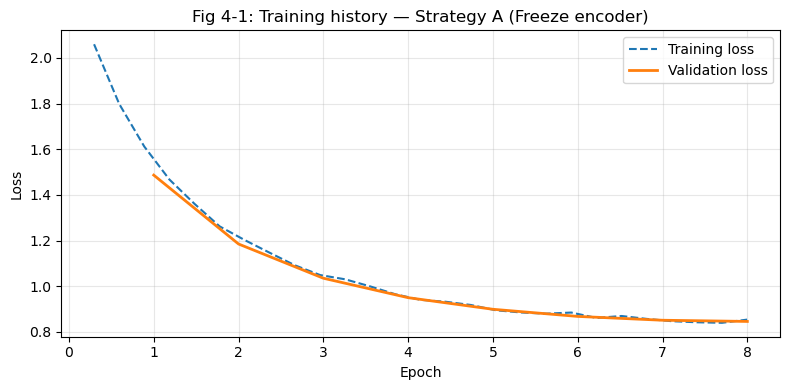

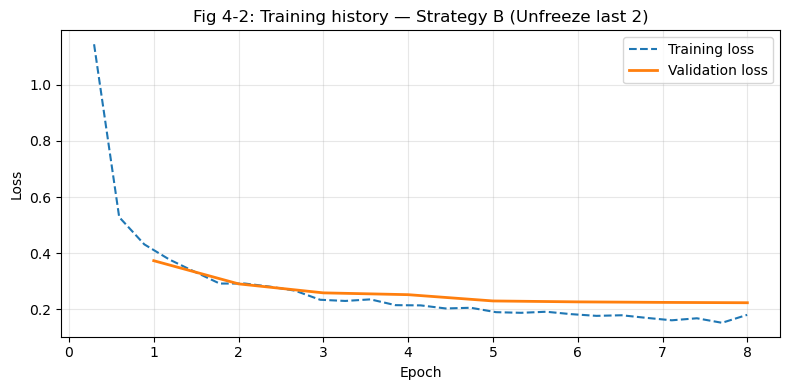

In [30]:
# Separate plots for each strategy
for label, tr_ep, tr_ls, val_ep, val_ls, fig_id in [
    ("A (Freeze encoder)", A_tr_ep, A_tr_ls, A_val_ep, A_val_ls, "4-1"),
    ("B (Unfreeze last 2)", B_tr_ep, B_tr_ls, B_val_ep, B_val_ls, "4-2"),
]:
    plt.figure(figsize=(8, 4))
    plt.plot(tr_ep,  tr_ls,  label="Training loss",   linestyle="--")
    plt.plot(val_ep, val_ls, label="Validation loss",  linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Fig {fig_id}: Training history — Strategy {label}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Saved: fig4_loss_curves.png


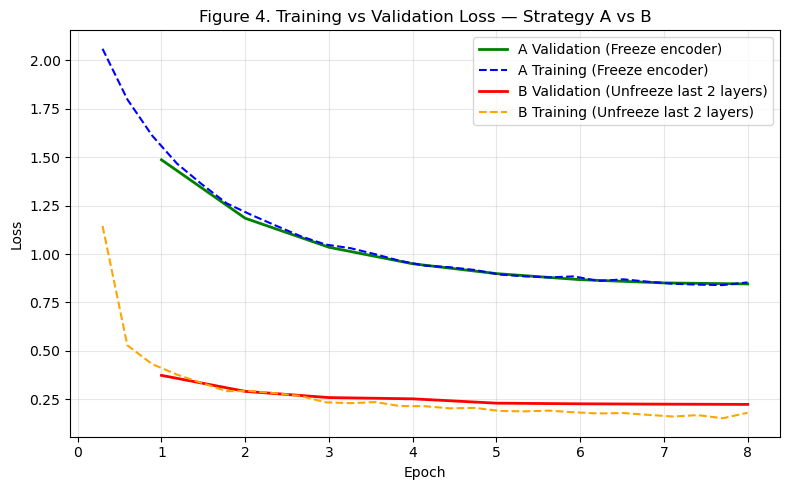

In [31]:
plt.figure(figsize=(8,5))

# --- Strategy A ---
plt.plot(A_val_ep, A_val_ls, label="A Validation (Freeze encoder)", color="green", linewidth=2)
plt.plot(A_tr_ep, A_tr_ls, label="A Training (Freeze encoder)", color="blue", linestyle="--", linewidth=1.5)

# --- Strategy B ---
plt.plot(B_val_ep, B_val_ls, label="B Validation (Unfreeze last 2 layers)", color="red", linewidth=2)
plt.plot(B_tr_ep, B_tr_ls, label="B Training (Unfreeze last 2 layers)", color="orange", linestyle="--", linewidth=1.5)

# --- Graph formatting ---
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Figure 4. Training vs Validation Loss — Strategy A vs B")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("fig4_loss_curves.png", dpi=200, bbox_inches="tight")
print("Saved: fig4_loss_curves.png")

plt.show()


=== Strategy A — Test metrics ===
{'test_loss': 0.7706333994865417, 'test_accuracy': 0.8012999071494893, 'test_runtime': 5.7037, 'test_samples_per_second': 377.65, 'test_steps_per_second': 23.669}

Classification report — Strategy A:
                                      precision    recall  f1-score   support

                             adipose       0.98      0.99      0.98       406
                          background       0.81      0.99      0.89       248
                              debris       0.54      0.39      0.45        85
                         lymphocytes       0.73      0.93      0.82       197
                               mucus       0.85      0.78      0.82       320
                       smooth muscle       0.67      0.67      0.67       164
                 normal colon mucosa       0.89      0.62      0.73       235
            cancer-associated stroma       0.48      0.37      0.42       122
colorectal adenocarcinoma epithelium       0.76      0.83     

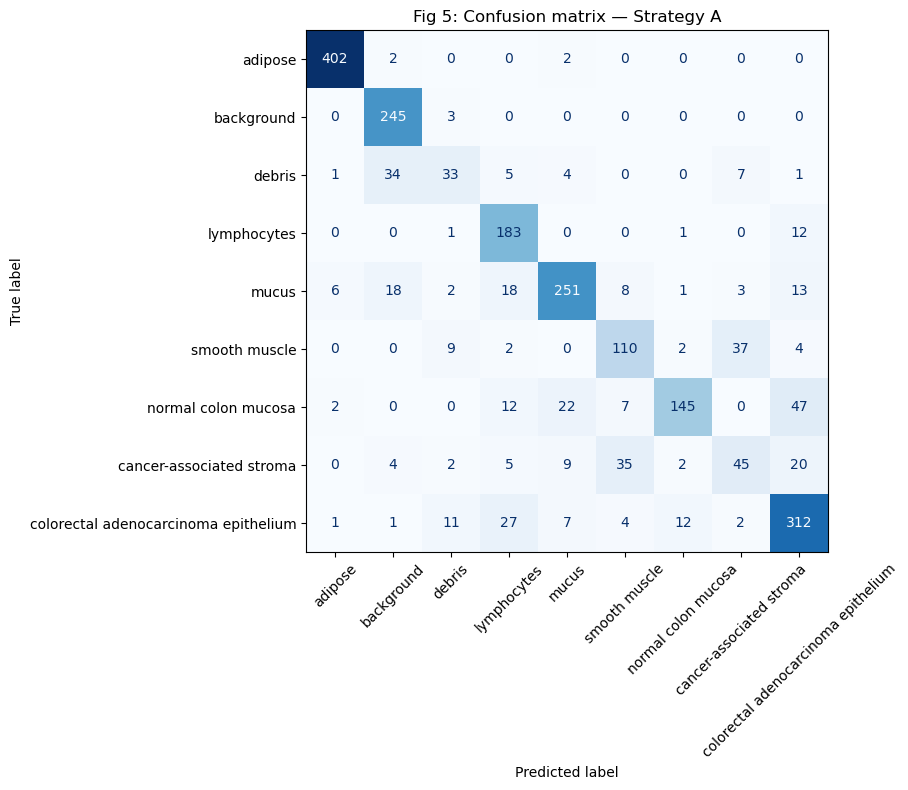


=== Strategy B — Test metrics ===
{'test_loss': 0.3113587200641632, 'test_accuracy': 0.904363974001857, 'test_runtime': 5.6278, 'test_samples_per_second': 382.74, 'test_steps_per_second': 23.988}

Classification report — Strategy B:
                                      precision    recall  f1-score   support

                             adipose       0.98      0.99      0.98       406
                          background       0.98      0.99      0.98       248
                              debris       0.61      0.82      0.70        85
                         lymphocytes       0.92      0.95      0.93       197
                               mucus       0.98      0.93      0.96       320
                       smooth muscle       0.76      0.79      0.77       164
                 normal colon mucosa       0.95      0.85      0.90       235
            cancer-associated stroma       0.67      0.52      0.59       122
colorectal adenocarcinoma epithelium       0.90      0.93      

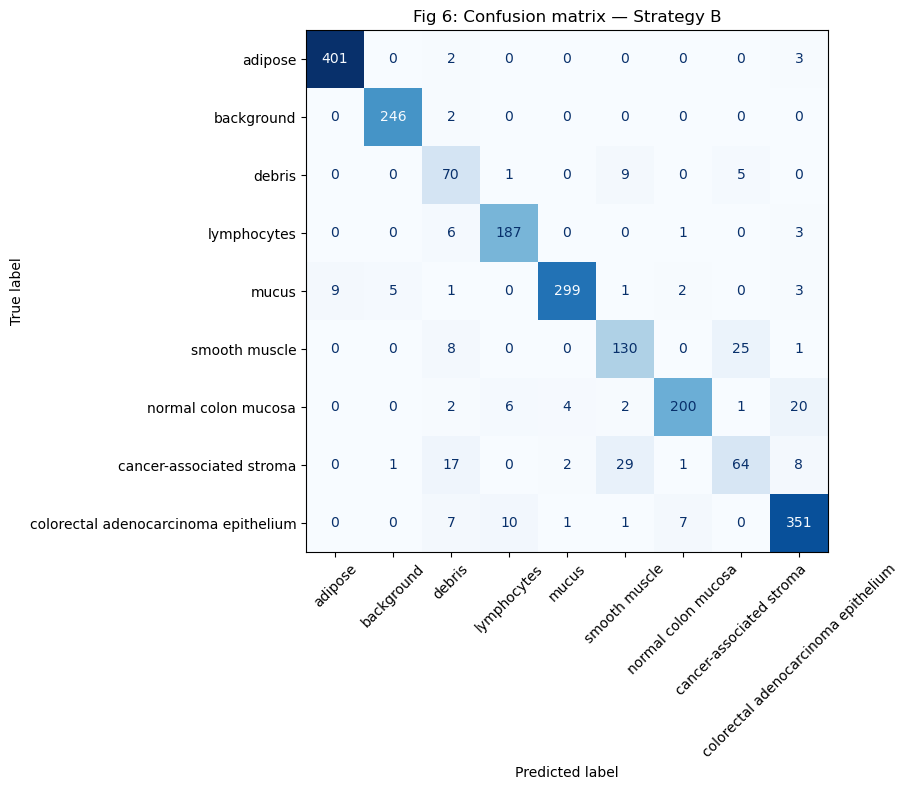

In [32]:
for trainer, name, fig_id in [(trainer_A, "A", "5"), (trainer_B, "B", "6")]:
    outputs = trainer.predict(dataset["test"])
    print(f"\n=== Strategy {name} — Test metrics ===")
    print(outputs.metrics)

    y_true = outputs.label_ids
    y_pred = outputs.predictions.argmax(1)

    # Classification report (precision / recall / F1 per class)
    print(f"\nClassification report — Strategy {name}:")
    print(classification_report(y_true, y_pred, target_names=labels))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
    ax.set_title(f"Fig {fig_id}: Confusion matrix — Strategy {name}")
    plt.tight_layout()

    filename = f"fig{fig_id}_confusion_strategy_{name}.png"
    plt.savefig(filename, dpi=200, bbox_inches="tight")
    print(f"Saved: {filename}")

    plt.show()

# 5. Embedding visualisation and clustering 
Embedding extraction

The CLS token from the final encoder layer (before the classifier head) is extracted 
for all test images. Shape: (N_test, 192). These 192-dimensional vectors are used for 
PCA, t-SNE visualisation, and K-means clustering.

In [33]:
def extract_embeddings(model, dataset):
    model.eval()

    all_emb = []
    all_labels = []

    for i in range(len(dataset["test"])):
        sample = dataset["test"][i]
        pixel_values = sample["pixel_values"].unsqueeze(0).to(model.device)
        label = sample["labels"]

        with torch.no_grad():
            outputs = model.vit(pixel_values=pixel_values)

        cls = outputs.last_hidden_state[:, 0, :].cpu()
        all_emb.append(cls)
        all_labels.append(label)

    all_emb = torch.cat(all_emb, dim=0).numpy()
    all_labels = np.array(all_labels)

    return all_emb, all_labels

In [34]:
def analyze_embeddings(all_emb, all_labels, labels, model_name="Model", fig_offset=0):
    label_text = [labels[i] for i in all_labels]

    # ===== FIGURE 1: PCA 2D =====
    pca_2d = PCA(n_components=2)
    pca_2d_scores = pca_2d.fit_transform(all_emb)

    plt.figure(figsize=(8,6))
    for lab in set(label_text):
        idx = [i for i, x in enumerate(label_text) if x == lab]
        plt.scatter(pca_2d_scores[idx, 0], pca_2d_scores[idx, 1], s=12, label=lab)

    plt.title(f"Figure {fig_offset}-1. PCA 2D — {model_name}")
    plt.legend(title="Classes", bbox_to_anchor=(1.05,1), loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.savefig(f"fig{fig_offset}_PCA2D_{model_name.replace(' ','_')}.png", dpi=200)
    plt.show()


    # ===== FIGURE 2: t‑SNE =====
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        max_iter=1000,
        init="pca",
        random_state=0,
    )
    tsne_emb = tsne.fit_transform(all_emb)

    plt.figure(figsize=(8,6))
    for lab in set(label_text):
        idx = [i for i, x in enumerate(label_text) if x == lab]
        plt.scatter(tsne_emb[idx,0], tsne_emb[idx,1], s=10, label=lab)

    plt.title(f"Figure {fig_offset}-2. t‑SNE — {model_name}")
    plt.legend(title="Classes", bbox_to_anchor=(1.05,1), loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.savefig(f"fig{fig_offset+1}_tSNE_{model_name.replace(' ','_')}.png", dpi=200)
    plt.show()


    # ===== KMeans (unscaled) =====
    kmeans = KMeans(n_clusters=len(labels), n_init=10, random_state=0)
    kmeans.fit(all_emb)
    kmeans_labels = kmeans.labels_
    ari = adjusted_rand_score(all_labels, kmeans_labels)
    print(f"{model_name} ARI:", ari)

    return {
        "pca_2d": pca_2d_scores,
        "tsne": tsne_emb,
        "kmeans_labels": kmeans_labels,
        "ari": ari
    }

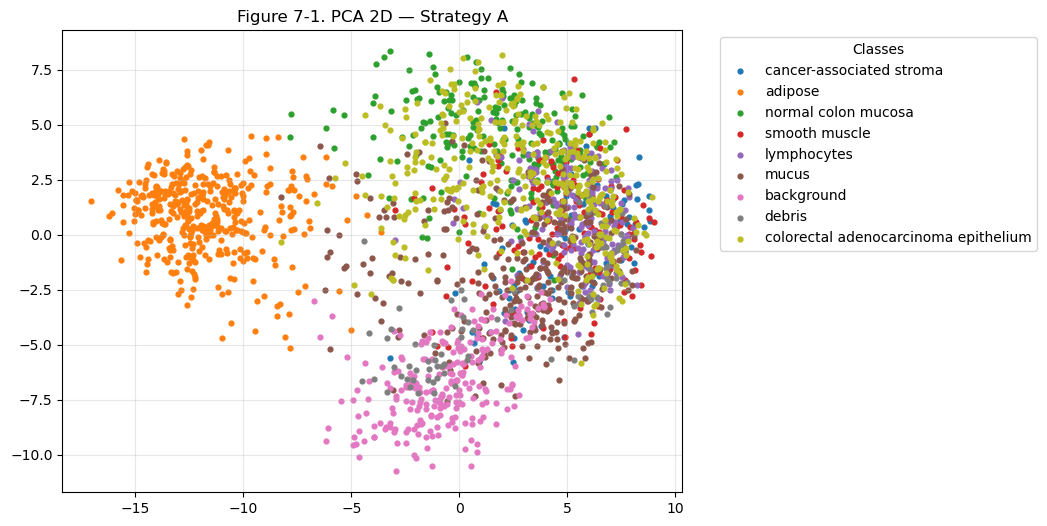

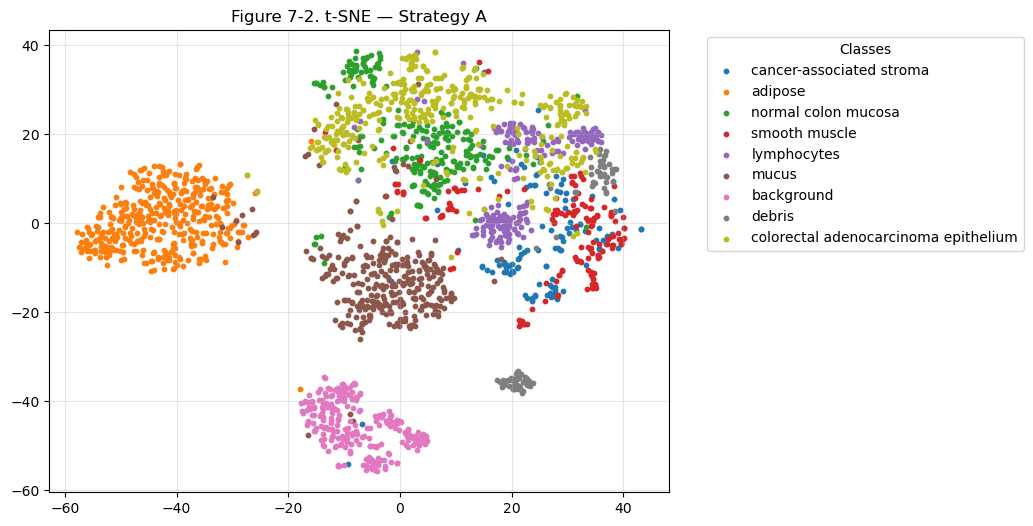

Strategy A ARI: 0.48158787285457977


In [35]:
emb_A, labels_A = extract_embeddings(model_A, dataset)
result_A = analyze_embeddings(emb_A, labels_A, labels, model_name="Strategy A", fig_offset=7)

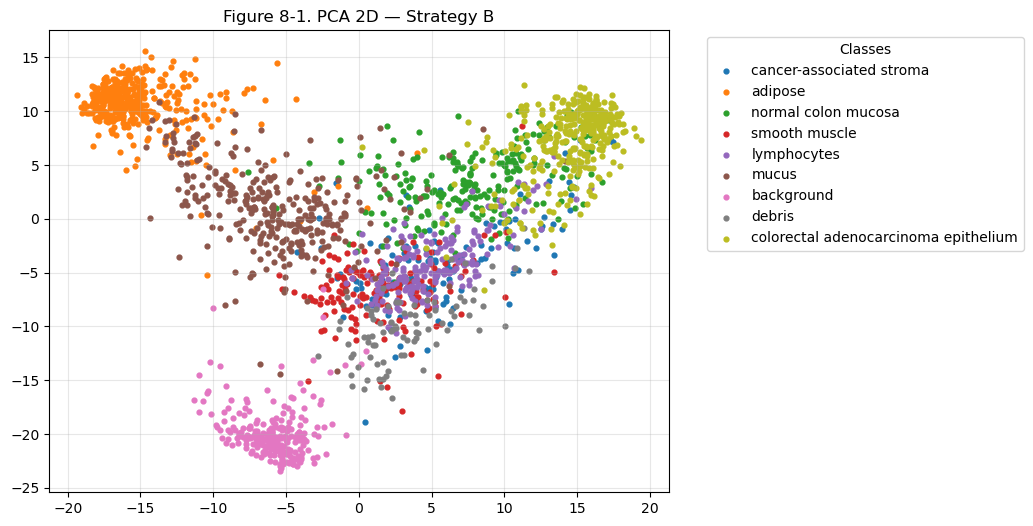

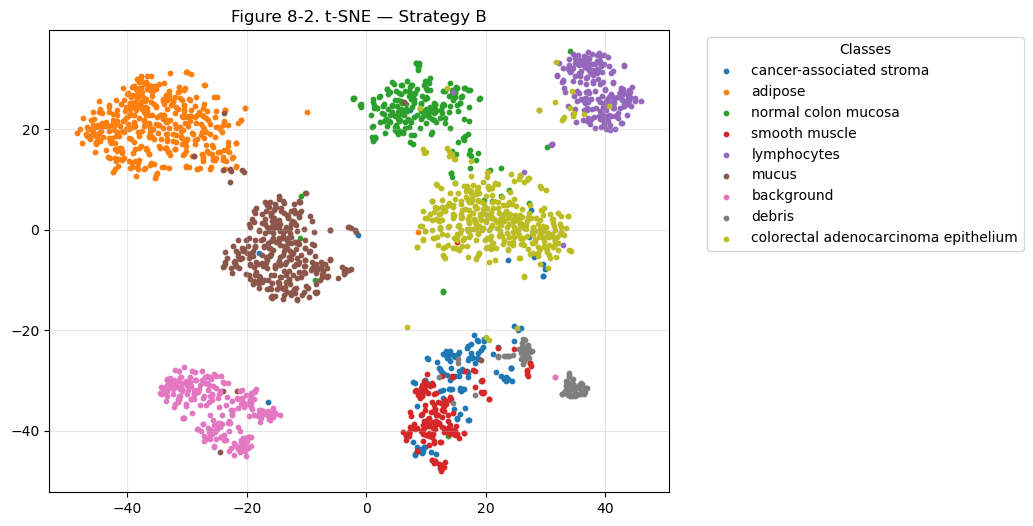

Strategy B ARI: 0.8744302629790941


In [36]:
emb_B, labels_B = extract_embeddings(model_B, dataset)
result_B = analyze_embeddings(emb_B, labels_B, labels, model_name="Strategy B", fig_offset=8)

### Combine as founction

In [31]:
def extract_embeddings(model, dataset):
    model.eval()

    all_emb = []
    all_labels = []

    for i in range(len(dataset["test"])):
        sample = dataset["test"][i]
        pixel_values = sample["pixel_values"].unsqueeze(0).to(model.device)
        label = sample["labels"]

        with torch.no_grad():
            outputs = model.vit(pixel_values=pixel_values)

        cls = outputs.last_hidden_state[:, 0, :].cpu()
        all_emb.append(cls)
        all_labels.append(label)

    all_emb = torch.cat(all_emb, dim=0).numpy()
    all_labels = np.array(all_labels)

    return all_emb, all_labels

In [37]:
def analyze_embeddings(all_emb, all_labels, labels, model_name="Model", fig_offset=0):
    label_text = [labels[i] for i in all_labels]

    # ===== PCA 2D =====
    pca_2d = PCA(n_components=2)
    pca_2d_scores = pca_2d.fit_transform(all_emb)

    plt.figure(figsize=(8,6))
    for lab in set(label_text):
        idx = [i for i, x in enumerate(label_text) if x == lab]
        plt.scatter(pca_2d_scores[idx, 0], pca_2d_scores[idx, 1], s=12, label=lab)

    plt.title(f"PCA 2D ({model_name})")
    plt.legend(title="Classes", bbox_to_anchor=(1.05,1), loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.show()

    # ===== TSNE =====
    tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    init="pca",
    random_state=0
)
    tsne_emb = tsne.fit_transform(all_emb)

    plt.figure(figsize=(8,6))
    for lab in set(label_text):
        idx = [i for i, x in enumerate(label_text) if x == lab]
        plt.scatter(tsne_emb[idx,0], tsne_emb[idx,1], s=10, label=lab)

    plt.title(f"t-SNE ({model_name})")
    plt.legend(bbox_to_anchor=(1.05,1))
    plt.grid(True, alpha=0.3)
    plt.show()

    # ===== KMeans =====
    kmeans = KMeans(n_clusters=len(labels), n_init=10, random_state=0)
    kmeans.fit(all_emb)

    kmeans_labels = kmeans.labels_

    ari = adjusted_rand_score(all_labels, kmeans_labels)
    print(f"{model_name} ARI:", ari)

    return {
        "pca_2d": pca_2d_scores,
        "tsne": tsne_emb,
        "kmeans_labels": kmeans_labels,
        "ari": ari
    }

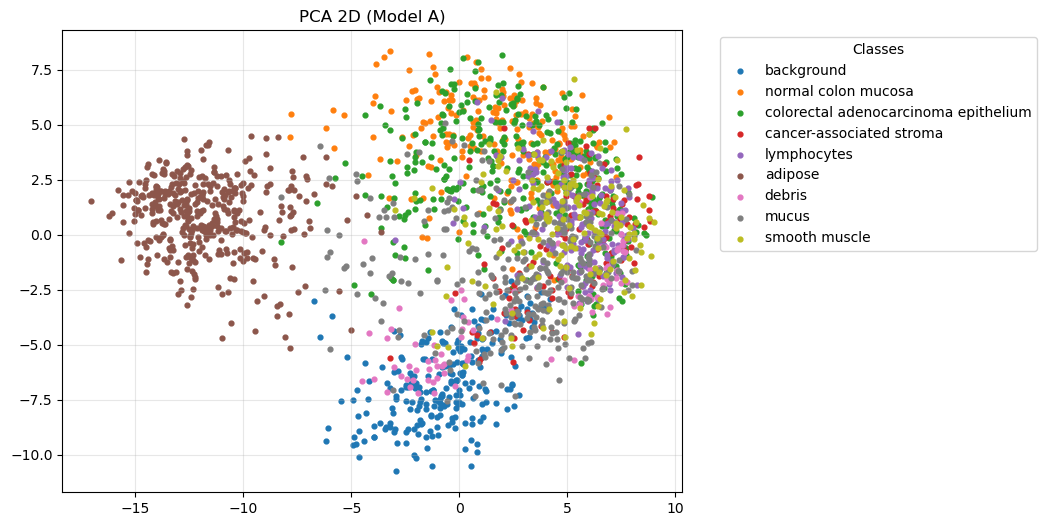

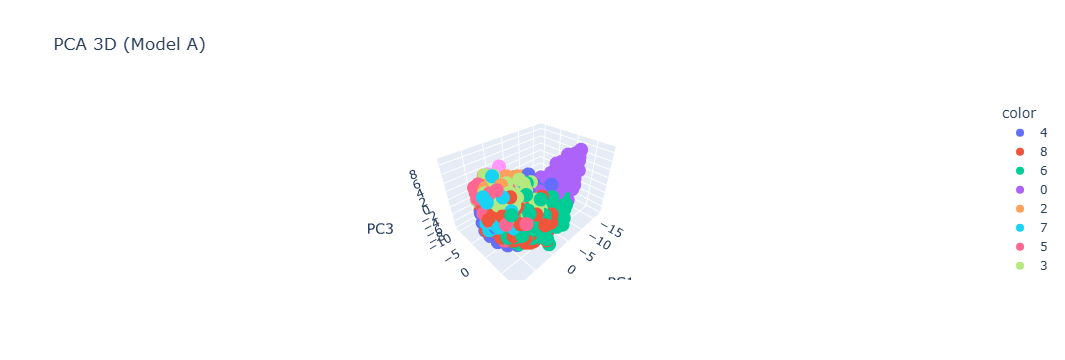

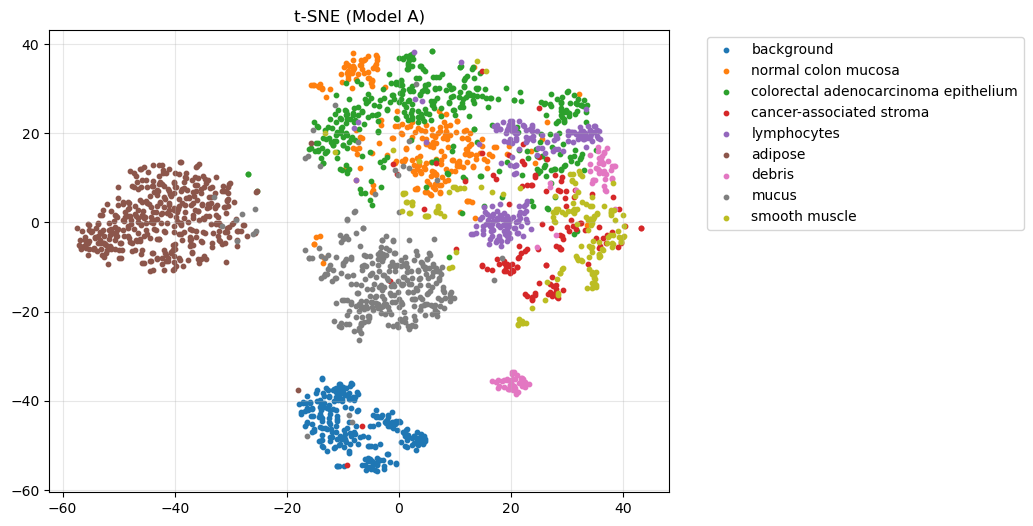

Model A ARI: 0.48158787285457977


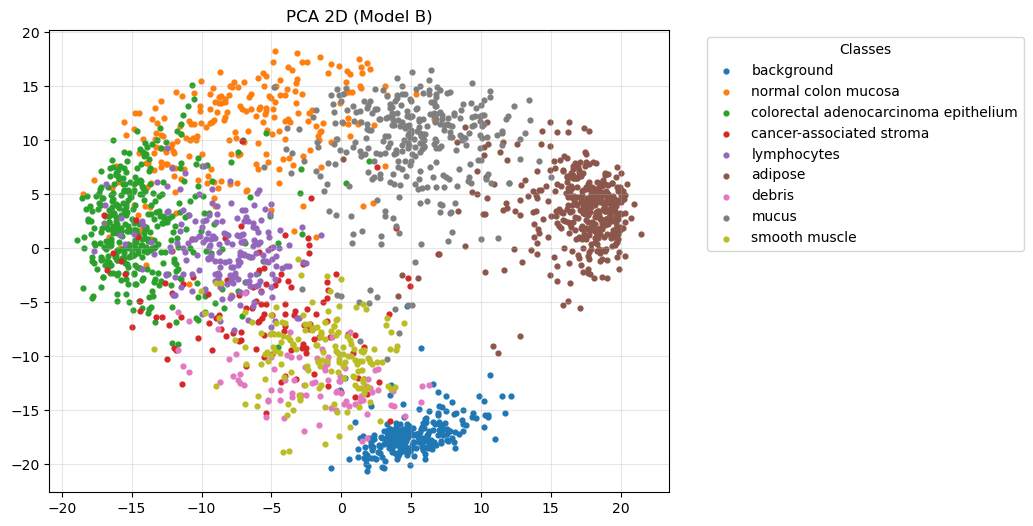

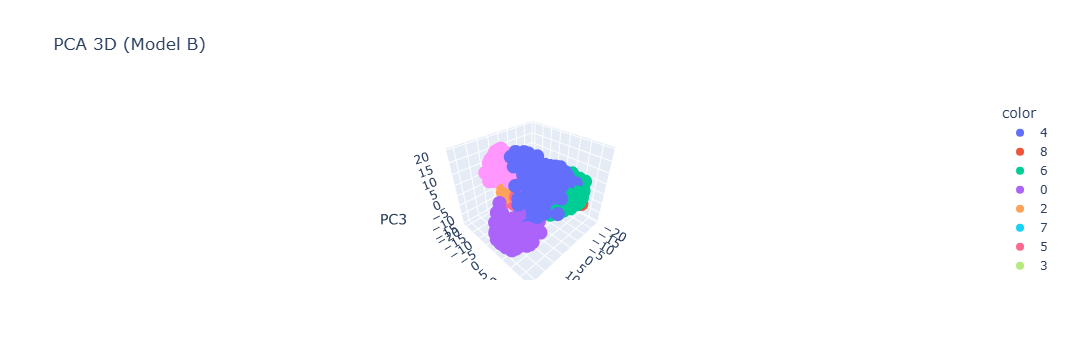

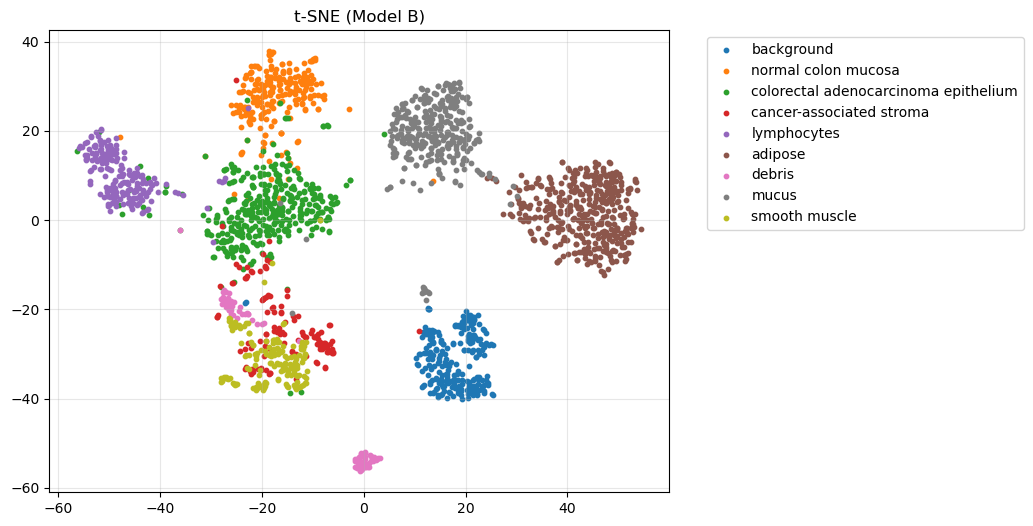

Model B ARI: 0.8605201579383205


In [38]:
# Model A
emb_A, labels_A = extract_embeddings(model_A, dataset)
result_A = analyze_embeddings(emb_A, labels_A, labels, model_name="Model A")

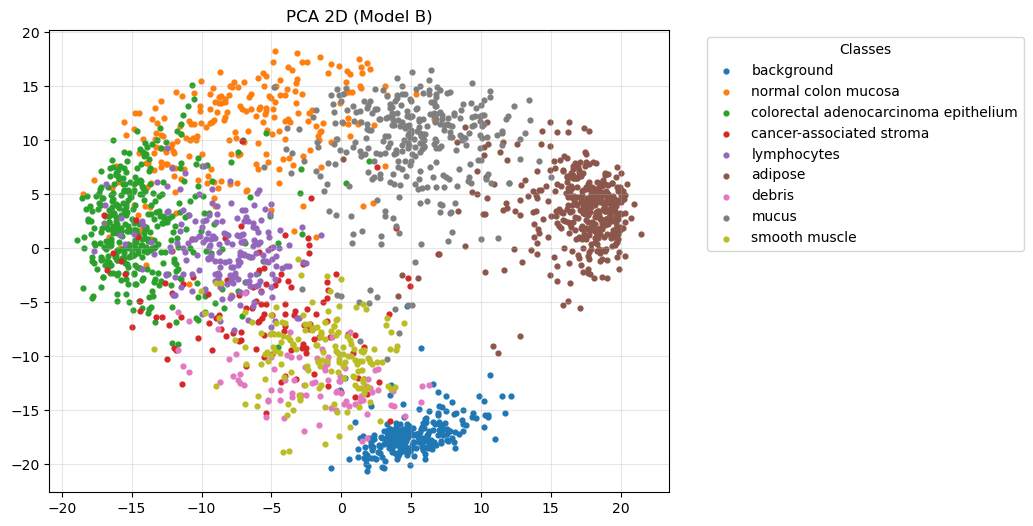

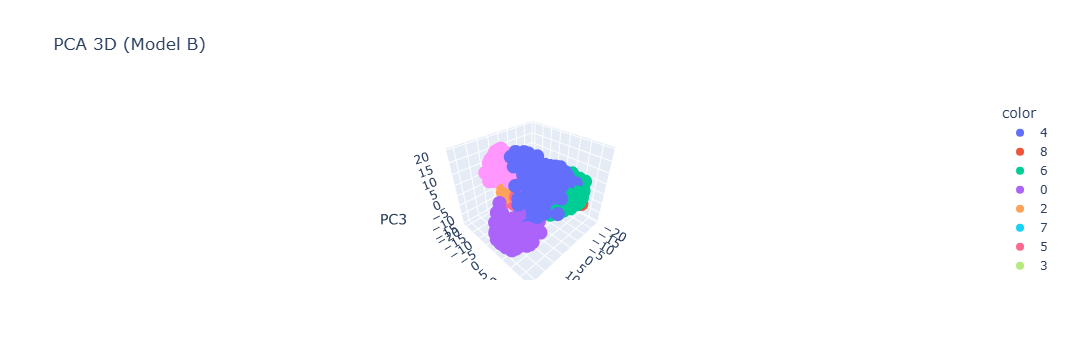

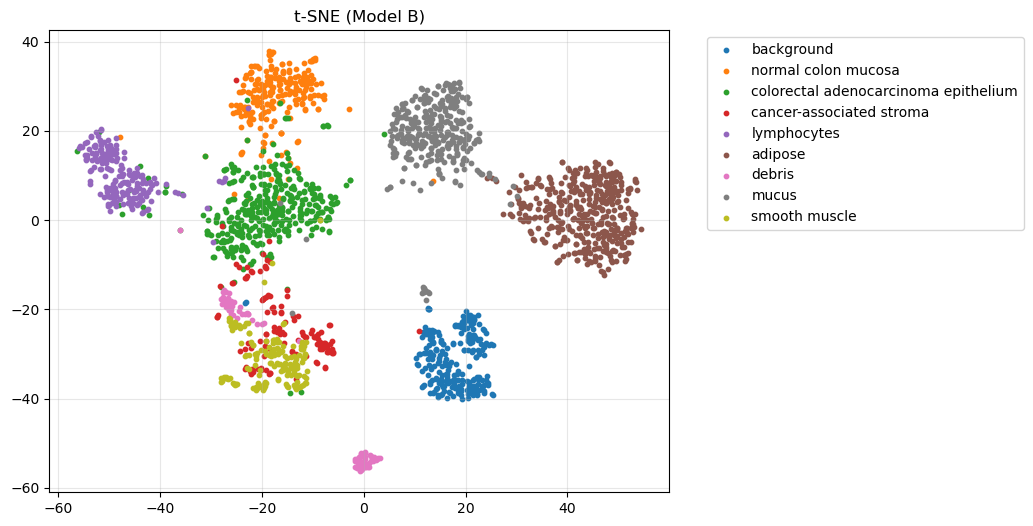

Model B ARI: 0.8605201579383205


In [39]:
# Model B
emb_B, labels_B = extract_embeddings(model_B, dataset)
result_B = analyze_embeddings(emb_B, labels_B, labels, model_name="Model B")

# Addiotional analysis

### 1. Scaling the Embeddings before K‑means (StandardScaler)
K‑means clustering relies entirely on Euclidean distance.

When different embedding dimensions have very different scales, the distance metric becomes distorted:

1. Large‑variance dimensions dominate the distance computation
2. Small‑variance dimensions contribute almost nothing
3. Clusters become mis‑shaped or misleading
4. ARI does not reflect the true quality of learned representations

Vision Transformer (ViT) CLS embeddings are 192‑dimensional with highly uneven per‑dimension variances.

Thus, applying StandardScaler ensures better representation of true embedding separability.

In [39]:
from sklearn.preprocessing import StandardScaler
def analyze_embeddings(all_emb, all_labels, labels, model_name="Model"):
    # ===== KMeans (UNSCALED) =====
    kmeans = KMeans(n_clusters=len(labels), n_init=10, random_state=0)
    kmeans.fit(all_emb)
    kmeans_labels = kmeans.labels_
    ari_unscaled = adjusted_rand_score(all_labels, kmeans_labels)
    print(f"{model_name} ARI (unscaled):", ari_unscaled)

    # ===== KMeans (SCALED) =====
    scaler = StandardScaler()
    all_emb_scaled = scaler.fit_transform(all_emb)

    kmeans_scaled = KMeans(n_clusters=len(labels), n_init=10, random_state=0)
    kmeans_scaled.fit(all_emb_scaled)
    kmeans_labels_scaled = kmeans_scaled.labels_
    ari_scaled = adjusted_rand_score(all_labels, kmeans_labels_scaled)
    print(f"{model_name} ARI (scaled):", ari_scaled)

    return {
        "ari_unscaled": ari_unscaled,
        "ari_scaled": ari_scaled
    }

In [40]:
# Model A_
emb_A, labels_A = extract_embeddings(model_A, dataset)
result_A = analyze_embeddings(emb_A, labels_A, labels, model_name="Model A")

Model A ARI (unscaled): 0.48158787285457977
Model A ARI (scaled): 0.4817875829983375


In [41]:
# Model B
emb_B, labels_B = extract_embeddings(model_B, dataset)
result_B = analyze_embeddings(emb_B, labels_B, labels, model_name="Model B")

Model B ARI (unscaled): 0.8744302629790941
Model B ARI (scaled): 0.8177641240146264


### 2. Lower Learning Rate for Strategy B (5e‑6)
Strategy B partially unfreezes the final Transformer encoder blocks.

If the learning rate is too high, the fine‑tuning step can damage pretrained representations.

Lowering the learning rate (5e‑6) to allows gentle adaptation to the new dataset.

In [43]:
model_B2 =  make_model()

for param in model_B2.vit.parameters():
    param.requires_grad = False
for param in model_B2.classifier.parameters():
    param.requires_grad = True
for param in model_B2.vit.encoder.layer[-2:].parameters():
    param.requires_grad = True

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 31297.27it/s]
ViTForImageClassification LOAD REPORT from: facebook/deit-tiny-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([9])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 192]) vs model:torch.Size([9, 192])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [44]:
training_args_B2 = TrainingArguments(
    output_dir="vit_finetune_B_lowLR",
    save_strategy="no",
    eval_strategy="epoch",
    learning_rate=5e-6, 
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir="logs_B_lowLR",
    remove_unused_columns=False,
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [45]:
trainer_B2 = Trainer(
    model=model_B,
    args=training_args_B2,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
)
trainer_B2.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.166630,0.230108,0.929690
2,0.160648,0.222483,0.928357
3,0.153357,0.222528,0.929357
4,0.154970,0.222080,0.931023
5,0.156371,0.220952,0.928357


TrainOutput(global_step=8440, training_loss=0.1561649177876694, metrics={'train_runtime': 440.6906, 'train_samples_per_second': 306.315, 'train_steps_per_second': 19.152, 'total_flos': 6.73741104169513e+17, 'train_loss': 0.1561649177876694, 'epoch': 5.0})

In [46]:
emb_B2, labels_B2 = extract_embeddings(model_B2, dataset)
result_B2 = analyze_embeddings(emb_B2, labels_B2, labels, model_name="Strategy B (LR=5e-6)")

Strategy B (LR=5e-6) ARI (unscaled): 0.48158787285457977
Strategy B (LR=5e-6) ARI (scaled): 0.4817875829983375


Although the model maintained high classification performance, the ARI dropped substantially to a level comparable with Strategy A. This suggests that reducing the learning rate limited the model’s ability to meaningfully adapt its internal feature representations, despite achieving similar predictive accuracy.

This highlights that strong classification performance does not necessarily imply well-structured embedding spaces, and that representation quality is sensitive to fine-tuning dynamics.